In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import fast_matrix_market as fmm
from sklearn.cluster import KMeans

In [3]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

### Generate Anndata object from gene count matrix and annotation file 

In [4]:
import scanpy as sc
import scipy.io

In [5]:
# GE matrix - how did they combine reads across DT and RH reads? 
ge_matrix="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_count.txt.gz"
# Metadata 
metadata="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_cell_annotation.csv.gz"
# Working directory 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/Seacells/"

# read cells file Cell_annotation.csv
cells = pd.read_csv('/gpfs/commons/groups/knowles_lab/data/sc/rockefeller_2022/Cell_annotation.csv')
# add a unique code to each row in cells dataframe just a number from 1 to nrow
cells["pair_code"] = range(1, len(cells) + 1)

# read the ad metadata file
metadata = pd.read_csv(metadata)

# Gene annotations 
gene_annots = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/EasySci-RNA-mouse-brain/GSM6538356_RNA_gene_annotation.csv.gz"

# Read in gene_annots and clean up dataframe 
gene_annots = pd.read_csv(gene_annots)

In [6]:
# make a dataframe for sample names and whether they are DT or RH 
samps_prime = cells[["Cell_random_hexamer", "pair_code"]].copy()
samps_prime["primer"] = " RH"
samps_prime.drop_duplicates(inplace=True)

# rename first column to "sample"
samps_prime = samps_prime.rename(columns={"Cell_random_hexamer": "sample"})
samps_prime_RH = samps_prime 

# now do the same for DT 
samps_prime = cells[["Cell_shortDT", "pair_code"]].copy()
samps_prime["primer"] = " DT"
samps_prime.drop_duplicates(inplace=True)

# rename first column to "sample"
samps_prime = samps_prime.rename(columns={"Cell_shortDT": "sample"})
samps_prime_DT = samps_prime

In [7]:
samps_prime = pd.concat([samps_prime_RH, samps_prime_DT])

In [8]:
# merge metadata with samps_prime on "sample"
metadata = metadata.merge(samps_prime, on="sample")

In [9]:
metadata.primer.value_counts() # this isn't actually meaningful though, seems for the metadata file they just chose one of the barcodes RH or RT to label the cell but the signal should be across both 

primer
 RH    737654
 DT    731457
Name: count, dtype: int64

In [10]:
# Replace 'data.mtx' with the path to your MatrixMarket file
matrix = fmm.mmread(ge_matrix)

In [11]:
# transpose matrix 
matrix = matrix.T

In [12]:
# convert COO to CSR or CSC sparse matrix
matrix = matrix.tocsr()

In [13]:
adata = sc.AnnData(X=matrix)

In [14]:
# now add gene_annots as gene annotations in the anndata object
adata.var = gene_annots

In [15]:
# create anndata object from gene_matrix and metadata
adata.obs = metadata

print("Done creating anndata object")

Done creating anndata object


### Pre-processing

The following section describes basic pre-processing steps for scRNA-seq.

In [16]:
# Copy the counts to ".raw" attribute of the anndata since it is necessary for downstream analysis
# This step should be performed after filtering 
ad = adata
raw_ad = sc.AnnData(ad.X)
raw_ad.obs_names, raw_ad.var_names = ad.obs_names, ad.var_names
ad.raw = raw_ad

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [17]:
sc.pp.normalize_total(ad, target_sum=1e4)  # Normalize to 10,000 reads per cell

In [18]:
# Log transform
sc.pp.log1p(ad)

In [19]:
# Compute highly variable genes
sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor="seurat_v3") # "seurat_v3" is a method similar to Seurat v3, which can handle large datasets efficiently.

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [20]:
# Compute principal components - 
# Here we use 50 components. This number may also be selected by examining variance explaint
sc.tl.pca(ad, n_comps=50, use_highly_variable=True)

In [21]:
# Subset adata object to contain just two major cell types 
# Check how many cells are in each cell type
print(ad.obs['Main_cluster_name'].value_counts())

Main_cluster_name
Cerebellum granule neurons           477790
Cortical projection neurons 1        177274
Interbrain and midbrain neurons 1    154645
Interbrain and midbrain neurons 2    143349
Oligodendrocytes                     104514
Astrocytes                            66383
Striatal neurons 1                    56080
Cortical projection neurons 2         39036
OB neurons 1                          37258
Cerebellum interneurons               27566
Interneurons 1                        27475
Oligodendrocyte progenitor cells      22718
Endothelial cells                     20362
Dentate gyrus neurons                 20110
Microglia                             16879
Interneurons 2                        16370
Purkinje neurons                      10439
Bergmann glia                          9478
Vascular leptomeningeal cells          8277
OB neurons 2                           6823
Choroid plexus epithelial cells        4379
Cortical projection neurons 3          4219
Hindbrain neur

In [22]:
# just want representaiton of a cell via DT and RH 
# can concatenate gene expression then PCA for representation and then kMeans 
# metacells them differently could have different pairs of cells being grouped together 
# kmeans initialize with k++ make sure!!! and how many multiple restarts 

In [23]:
# batch effects? Replicate_ID ? 

### Running K-means to get metacells

As a rule of thumb, we recommended choosing one metacell for every 75 single-cells. Since this dataset contains ~7k cells, we choose 90 metacells.

Note 1: Running SEACells modifies the input Anndata object and adds the SEACell metacell assignments to the obs dataframe in the anndata object. Note 2: This analysis takes approxmiately 5 minutes

In [24]:
num_cells = ad.shape[0]
print(f"Number of cells: {num_cells}")

num_metacells = num_cells / 75
print(f"Number of metacells: {num_metacells}") 
# round num_meta_cells to the nearest integer 
num_metacells = int(round(num_metacells))
print(f"Number of rounded metacells to learn: {num_metacells}")

Number of cells: 1469111
Number of metacells: 19588.146666666667
Number of rounded metacells to learn: 19588


In [25]:
# renumber the index in adata_subset 
ad.obs_names = [f"cell-{i}" for i in range(ad.shape[0])]

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


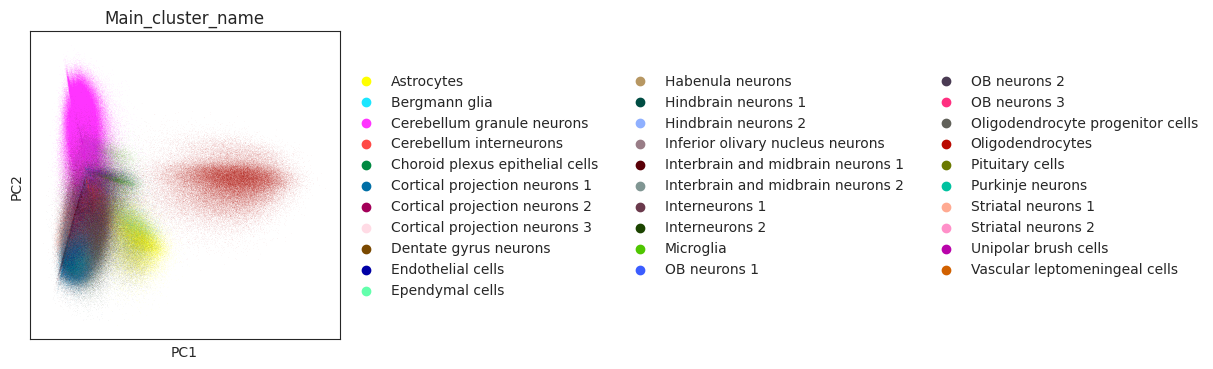

In [26]:
# plot PCs 1 vs 2 
sc.pl.pca(ad, color='Main_cluster_name')

In [27]:
# Step 1: Perform K-means clustering on PCA coordinates
n_clusters = num_metacells  # Adjust the number of clusters as needed

In [28]:
ad.obsm['X_pca']

array([[-1.6397239 ,  4.8663654 ,  0.23539695, ...,  0.41068977,
        -0.6953686 , -0.0289667 ],
       [-1.4126407 , -3.0407605 , -1.2680632 , ..., -0.16099271,
        -0.33672452,  0.01486073],
       [-1.3495423 , -0.7128968 , -1.2648889 , ..., -0.3339866 ,
         1.2852024 , -1.1906261 ],
       ...,
       [-1.5434753 ,  4.5726666 ,  0.75132155, ...,  0.21245319,
         0.4619359 ,  1.9602634 ],
       [ 2.633257  , -1.0330566 ,  6.1210546 , ..., -0.33453137,
         0.23754783,  0.2835109 ],
       [ 2.486149  , -1.9108083 ,  8.56714   , ...,  0.88292986,
         0.8469421 , -0.05760193]], dtype=float32)

In [29]:
# let's subset ad data to just 1000 cells and try out kmeans 
ad_subset = ad[:1000000, :]
ad_subset.obsm["X_pca"].shape

(1000000, 50)

In [30]:
# ‘k-means++’ : selects initial cluster centroids using sampling based on an empirical probability distribution of the points’ contribution to the overall inertia. 
#  This technique speeds up convergence. The algorithm implemented is “greedy k-means++”. It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.

In [31]:
kmeans = KMeans(n_clusters=1000, random_state=42, init='k-means++', n_init=1, verbose=1)
kmeans.fit(ad_subset.obsm['X_pca'])  # Using PCA coordinates for clustering

Initialization complete
Iteration 0, inertia 23639850.0.
Iteration 1, inertia 20146160.0.
Iteration 2, inertia 19709768.0.
Iteration 3, inertia 19481252.0.
Iteration 4, inertia 19340818.0.
Iteration 5, inertia 19250880.0.
Iteration 6, inertia 19188202.0.
Iteration 7, inertia 19140564.0.
Iteration 8, inertia 19103924.0.
Iteration 9, inertia 19076114.0.
Iteration 10, inertia 19053978.0.
Iteration 11, inertia 19036824.0.
Iteration 12, inertia 19022544.0.
Iteration 13, inertia 19010352.0.
Iteration 14, inertia 18999924.0.
Iteration 15, inertia 18990884.0.
Iteration 16, inertia 18982790.0.
Iteration 17, inertia 18975066.0.
Iteration 18, inertia 18967164.0.
Iteration 19, inertia 18960788.0.
Iteration 20, inertia 18955976.0.
Iteration 21, inertia 18952018.0.
Iteration 22, inertia 18948348.0.
Iteration 23, inertia 18945230.0.
Iteration 24, inertia 18942484.0.
Iteration 25, inertia 18939966.0.
Iteration 26, inertia 18937330.0.
Iteration 27, inertia 18935112.0.
Iteration 28, inertia 18933064.0.


KMeans(n_clusters=1000, n_init=1, random_state=42, verbose=1)

In [32]:
# Step 2: Get cluster labels
cluster_labels = kmeans.labels_

In [33]:
cluster_labels

array([539, 519,  44, ..., 577, 262, 382], dtype=int32)

In [36]:
ad_subset

View of AnnData object with n_obs × n_vars = 1000000 × 55416
    obs: 'sample', 'UMI_count', 'Gene_count', 'PCR_sample_name', 'Ligation_barcode', 'RT_barcode', 'umap_1', 'umap_2', 'Louvain_cluster', 'Type', 'Sex', 'Replicate_ID', 'Main_cluster_name', 'Subcluster_id', 'Subcluster_umap_1', 'Subcluster_umap_2', 'Sub_cluster_num', 'pair_code', 'primer'
    var: 'gene_id', 'gene_type', 'gene_short_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'Main_cluster_name_colors'
    obsm: 'X_pca'
    varm: 'PCs'

In [37]:
# add cluster_labels to ad_subset obs 
ad_subset.obs['metacell'] = cluster_labels
ad_subset.obs.head()

/scratch/ipykernel_2740/1510971125.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_subset.obs['metacell'] = cluster_labels
/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,sample,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num,pair_code,primer,metacell
cell-0,EasySci_001.AACCGATTGCAATCGAACTC,558,379,EasySci_001,AACCGATTGC,AATCGAACTC,0.345946,4.792399,7,5xFAD,male,1,Cerebellum granule neurons,Cerebellum granule neurons_1,1.337663,-3.196105,1.0,1,DT,539
cell-1,EasySci_001.AACCGATTGCACTCCGCCAA,3180,1371,EasySci_001,AACCGATTGC,ACTCCGCCAA,7.559918,-3.935702,6,3mo,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_1,-0.875215,-2.433680,1.0,2,DT,519
cell-2,EasySci_001.AACCGATTGCAGCGATCCGC,3132,1657,EasySci_001,AACCGATTGC,AGCGATCCGC,8.763198,-3.253150,31,6mo,male,1,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_2,2.808076,3.226601,2.0,3,DT,44
cell-3,EasySci_001.AACCGATTGCCATCCAGCCA,10028,3436,EasySci_001,AACCGATTGC,CATCCAGCCA,7.853685,-3.673076,30,APOE4/TREM2,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_3,1.555948,0.093578,3.0,4,DT,899
cell-4,EasySci_001.AACCGATTGCCCAGGCTCTT,953,610,EasySci_001,AACCGATTGC,CCAGGCTCTT,-7.504099,0.636785,47,6mo,male,1,Oligodendrocyte progenitor cells,Oligodendrocyte progenitor cells_1,3.020408,-0.754258,1.0,5,DT,640


In [39]:
ad_subset.obs[ad_subset.obs["sample"] == "EasySci_001.AACCGATTGCCATCCAGCCA"]

,sample,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num,pair_code,primer,metacell
cell-3,EasySci_001.AACCGATTGCCATCCAGCCA,10028,3436,EasySci_001,AACCGATTGC,CATCCAGCCA,7.853685,-3.673076,30,APOE4/TREM2,male,2,Interbrain and midbrain neurons 2,Interbrain and midbrain neurons 2_3,1.555948,0.093578,3.0,4,DT,899


In [41]:
ad_subset.obs.primer.value_counts()

primer
 RH    502454
 DT    497546
Name: count, dtype: int64

/gpfs/commons/home/kisaev/miniconda3/envs/Seacells/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


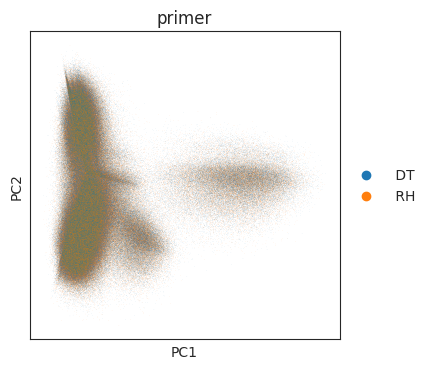

In [42]:
# plot PCs plot but colour by primer type 
sc.pl.pca(ad_subset, color='primer')

In [48]:
cells[cells["Cell_random_hexamer"] == "EasySci_077.ATAATAATCCTAACCTTCGG"]

,Cell_random_hexamer,Cell_shortDT,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode_random_hexamer,RT_barcode_shortDT,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num,pair_code
596915,EasySci_077.ATAATAATCCTAACCTTCGG,EasySci_077.ATAATAATCCCCGATTCCTG,397,255,EasySci_077,ATAATAATCC,TAACCTTCGG,CCGATTCCTG,1.083788,3.339389,2,21mo,female,1,Cerebellum granule neurons,Cerebellum granule neurons_5,-0.913491,1.911044,5.0,596916


In [50]:
ad.obs[ad.obs["sample"] == "EasySci_077.ATAATAATCCCCGATTCCTG"]

,sample,UMI_count,Gene_count,PCR_sample_name,Ligation_barcode,RT_barcode,umap_1,umap_2,Louvain_cluster,Type,Sex,Replicate_ID,Main_cluster_name,Subcluster_id,Subcluster_umap_1,Subcluster_umap_2,Sub_cluster_num,pair_code,primer
cell-596915,EasySci_077.ATAATAATCCCCGATTCCTG,397,255,EasySci_077,ATAATAATCC,CCGATTCCTG,1.083788,3.339389,2,21mo,female,1,Cerebellum granule neurons,Cerebellum granule neurons_5,-0.913491,1.911044,5.0,596916,DT
